/GPUFS/sysu_lhong_1/.conda/envs/pytorchgpu/lib/python3.6/site-packages/tqdm/auto.py:22: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


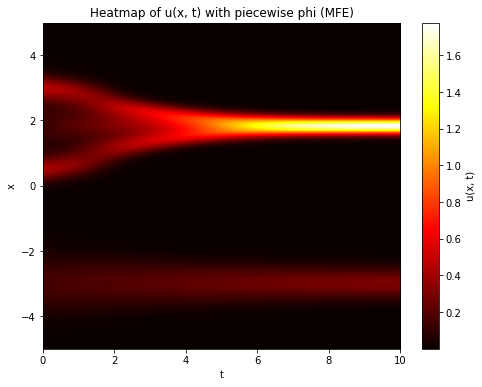

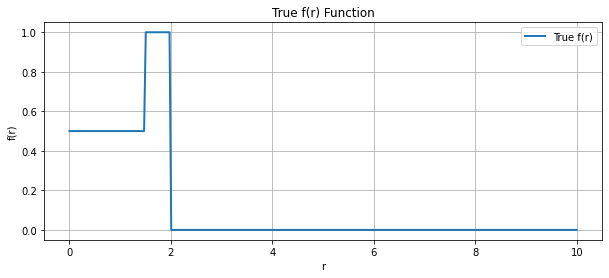

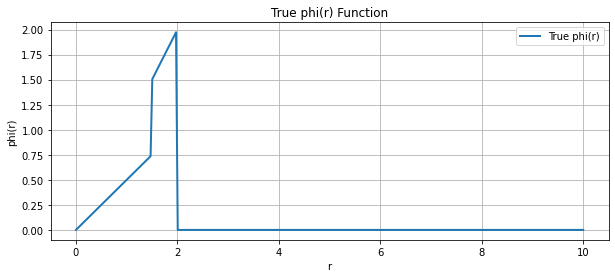

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm
from scipy.signal import convolve
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F


# SDE particle system simulation parameters
x_min, x_max = -5, 5
t_min, t_max = 0, 10
dx = 0.05
dt = 0.001
nu = 0.01 

nx = int((x_max - x_min) / dx) + 1
nt = int((t_max - t_min) / dt) + 1

x = np.linspace(x_min, x_max, nx)
t = np.linspace(t_min, t_max, nt)

u = np.zeros((nt, nx))
u[0, :] = (1/4)*(norm.pdf(x, -3, 0.64) + norm.pdf(x, 0.5, 0.25) + norm.pdf(x, 2, 0.81) + norm.pdf(x, 3, 0.25))

def f_true(r):

    res = np.zeros_like(r)
    mask1 = (r >= 0) & (r <= 1.5)      
    mask2 = (r > 1.5) & (r <= 2)      
    mask3 = (r > 2)                  
    res[mask1] = 0.5                
    res[mask2] = 1.0                  
    res[mask3] = 0             
    return res


def phi_true_func(r):
    return f_true(r) * r

def K_phi_true(x):
    abs_x = np.abs(x)
    sign_x = np.sign(x)
    return phi_true_func(abs_x) * sign_x

def convolve_K_phi_u(u_vector, x):
    K_phi_values = K_phi_true(x)
    return convolve(u_vector, K_phi_values, mode='same') * dx

def compute_rhs(u_vector, x):

    uxx = (np.roll(u_vector, -1) - 2*u_vector + np.roll(u_vector, 1)) / dx**2
    nu_uxx = nu * uxx
    conv_term = convolve_K_phi_u(u_vector, x)
    uxKphi = (np.roll(u_vector * conv_term, -1) - np.roll(u_vector * conv_term, 1)) / (2 * dx)
    return nu_uxx + uxKphi

for n in range(nt-1):
    k1 = dt * compute_rhs(u[n, :], x)
    k2 = dt * compute_rhs(u[n, :] + 0.5*k1, x)
    k3 = dt * compute_rhs(u[n, :] + 0.5*k2, x)
    k4 = dt * compute_rhs(u[n, :] + k3, x)
    u[n+1, :] = u[n, :] + (k1 + 2*k2 + 2*k3 + k4) / 6

plt.figure(figsize=(8, 6))
plt.imshow(u.T, extent=[t_min, t_max, x_min, x_max],
           aspect='auto', cmap='hot', origin='lower')
plt.colorbar(label='u(x, t)')
plt.xlabel('t')
plt.ylabel('x')
plt.title('Heatmap of u(x, t) with piecewise phi (MFE)')
plt.show()




使用 2 个GPU进行训练
Epoch 500/10000, Loss: 0.000054


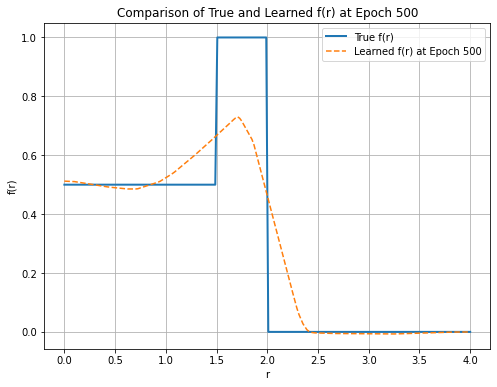

Epoch 1000/10000, Loss: 0.000014


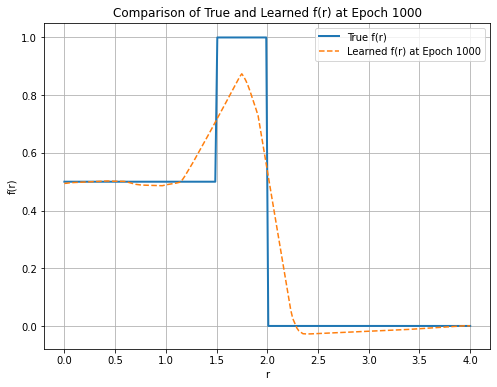

Epoch 1500/10000, Loss: 0.000008


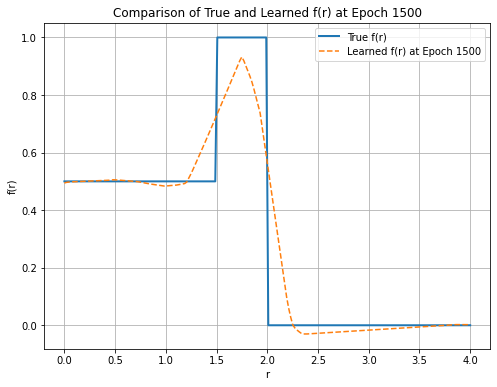

Epoch 2000/10000, Loss: 0.000008


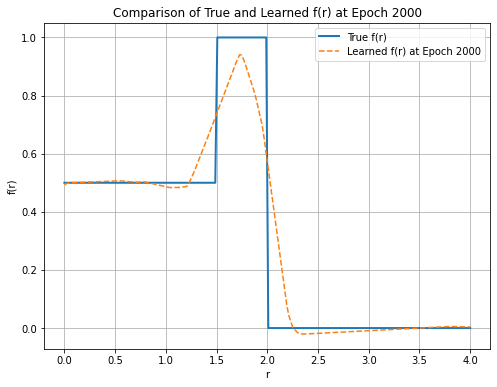

Epoch 2500/10000, Loss: 0.000005


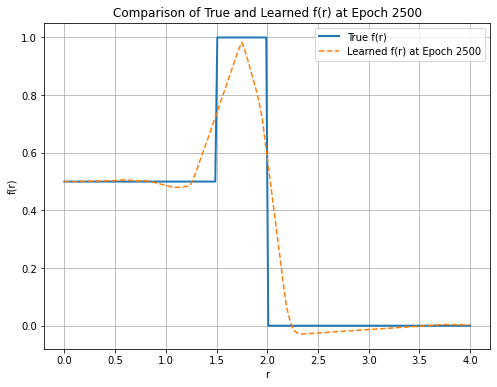

Epoch 3000/10000, Loss: 0.000007


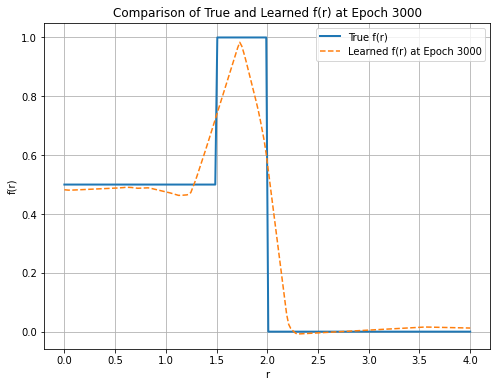

Epoch 3500/10000, Loss: 0.000003


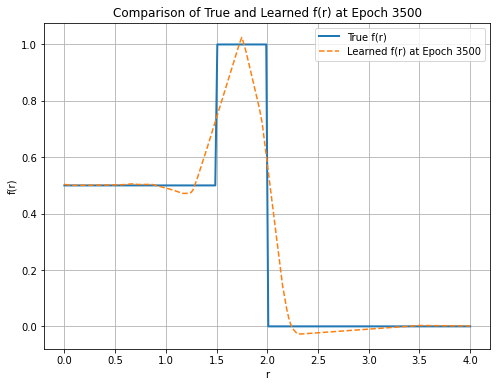

Epoch 4000/10000, Loss: 0.000007


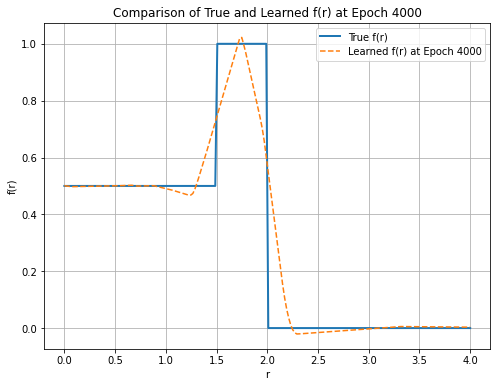

Epoch 4500/10000, Loss: 0.000017


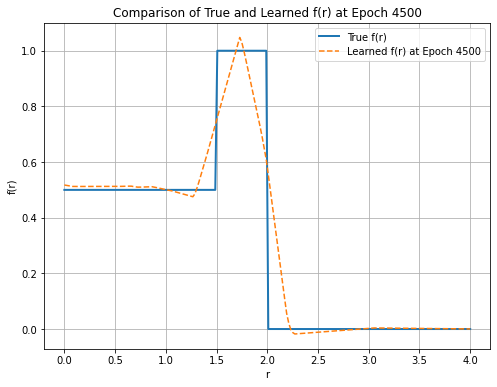

Epoch 5000/10000, Loss: 0.000002


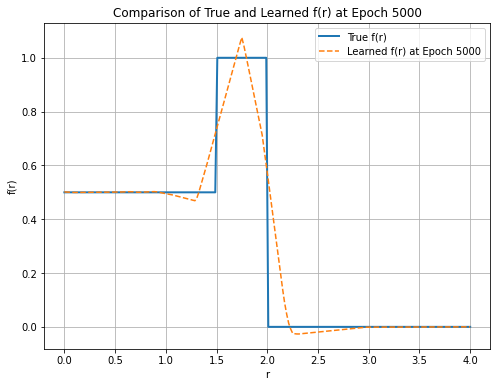

Epoch 5500/10000, Loss: 0.000058


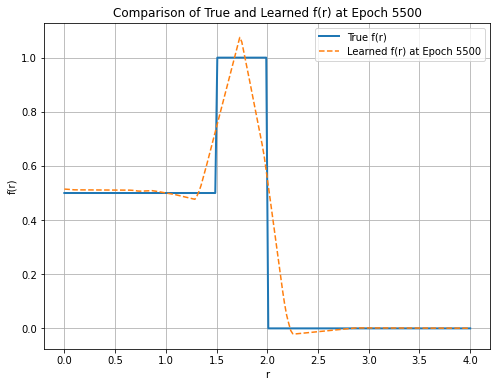

Epoch 6000/10000, Loss: 0.000002


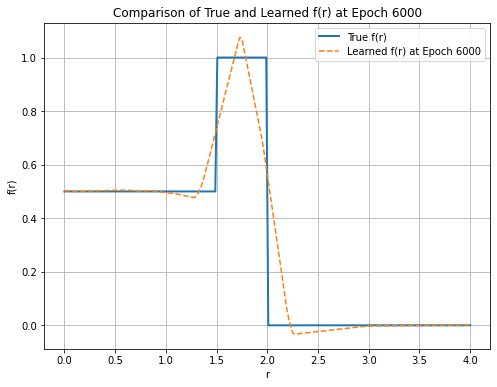

Epoch 6500/10000, Loss: 0.000005


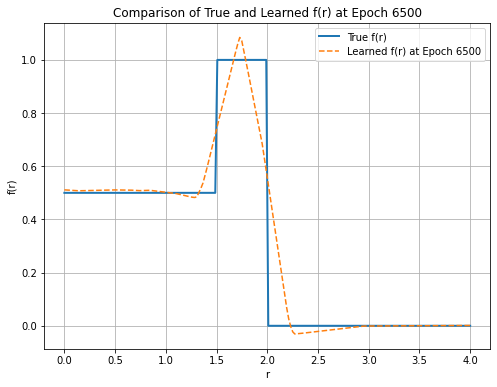

Epoch 7000/10000, Loss: 0.000042


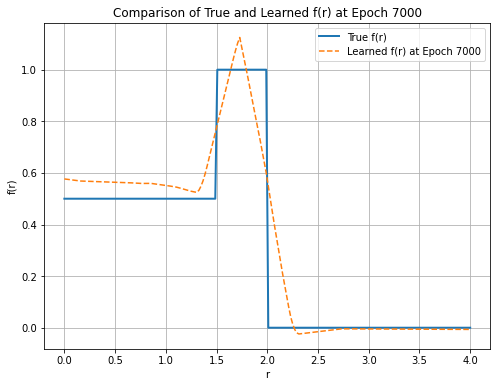

Epoch 7500/10000, Loss: 0.000002


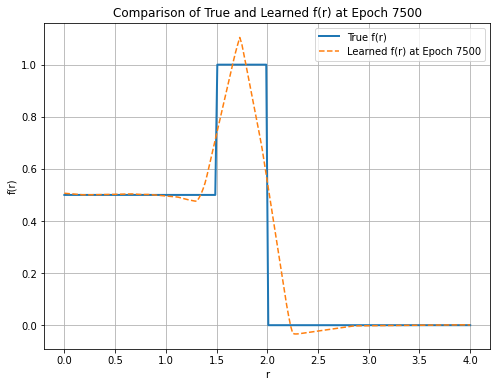

Epoch 8000/10000, Loss: 0.000001


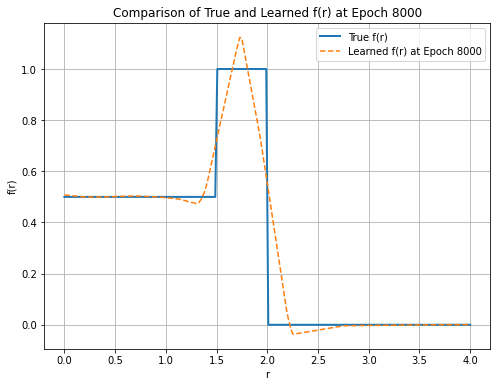

Epoch 8500/10000, Loss: 0.000007


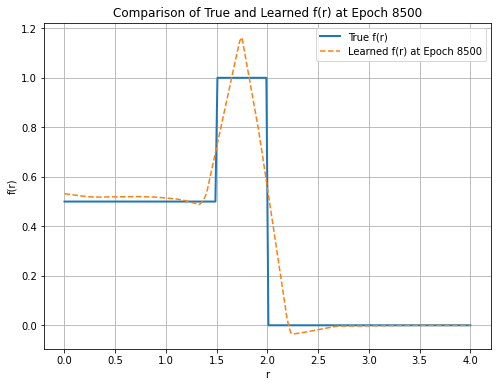

Epoch 9000/10000, Loss: 0.000001


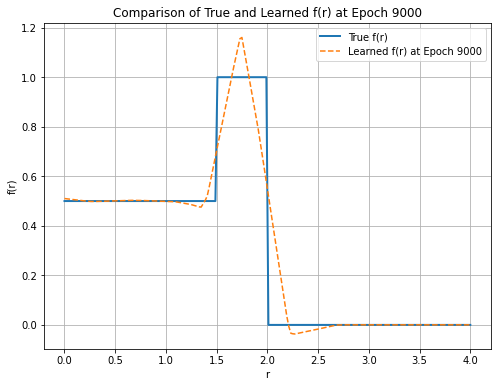

Epoch 9500/10000, Loss: 0.000001


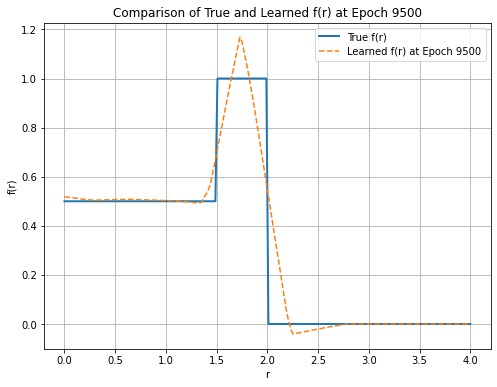

Epoch 10000/10000, Loss: 0.000000


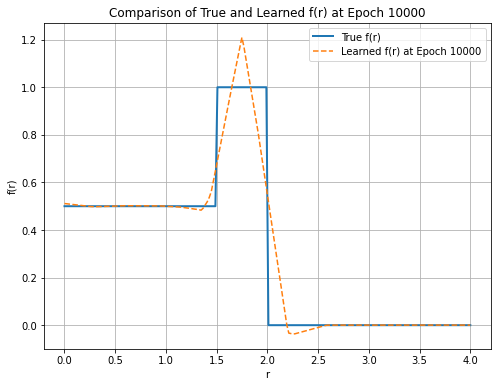

In [4]:
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
import matplotlib.pyplot as plt




u_t = (u[1:] - u[:-1]) / dt
u_t = np.vstack([u_t, np.zeros((1, nx))])  


u_xx = (np.roll(u, -1, axis=1) - 2*u + np.roll(u, 1, axis=1)) / dx**2


device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# Define NN to represent f
class FNNC(nn.Module):
    def __init__(self, hidden_size=64):
        super(FNNC, self).__init__()
        self.fc1 = nn.Linear(1, hidden_size)
        self.fc2 = nn.Linear(hidden_size, hidden_size)
        self.fc3 = nn.Linear(hidden_size, 1)
        self.activation = nn.ReLU()  

    def forward(self, r):
        x = self.activation(self.fc1(r))
        x = self.activation(self.fc2(x))
        x = self.fc3(x)
        return x  


f_model = FNNC(hidden_size=64).to(device)


if torch.cuda.device_count() > 1:
    print(f"Use {torch.cuda.device_count()} GPUs for training")
    f_model = nn.DataParallel(f_model)


optimizer = optim.Adam(f_model.parameters(), lr=1e-2)

# Preprocess data: Convert numpy array to Torch tensor and move to device
u_t_torch = torch.tensor(u_t, dtype=torch.float32).to(device)       # (nt, nx)
u_xx_torch = torch.tensor(u_xx, dtype=torch.float32).to(device)     # (nt, nx)
u_torch = torch.tensor(u, dtype=torch.float32).to(device)          # (nt, nx)
x_torch = torch.tensor(x, dtype=torch.float32).to(device)          # (nx,)

# Calculate x_center and related variables
x_center = x_torch[len(x)//2]
shifted_x = x_torch - x_center                                    # (nx,)
abs_x = torch.abs(shifted_x)                                      # (nx,)
sign_x = torch.sign(shifted_x).unsqueeze(1)                       # (nx, 1)


num_epochs = 10000
print_interval = 500  

for epoch in range(num_epochs):
    optimizer.zero_grad()
    
    # Calculate f(abs_x) and phi_val
    # abs_x: (nx,) -> (nx,1)
    abs_x_unsq = abs_x.unsqueeze(1)  # (nx,1)
    f_val = f_model(abs_x_unsq)      # (nx,1)
    phi_val = f_val * abs_x_unsq     # (nx,1)
    
    # Deal with the situation when r=0, phi(0)=0
    K_val = (phi_val * sign_x).squeeze(1)  # (nx,)

    # Batch convolution
    # K_val: (nx,) -> (1,1,nx)
    K_val_torch = K_val.unsqueeze(0).unsqueeze(0)      # (1,1,nx)
    K_val_torch = torch.flip(K_val_torch, [2])         # flip core

    # u_torch: (nt, nx) -> (nt,1,nx)
    u_input = u_torch.unsqueeze(1)                     # (nt,1,nx)

    conv_Ku = F.conv1d(u_input, K_val_torch, padding=K_val_torch.shape[-1]//2) * dx  # (nt,1,nx)
    conv_Ku = conv_Ku.squeeze(1)                        # (nt, nx)

    uKu = u_torch * conv_Ku                              # (nt, nx)
    grad_uKu = (torch.roll(uKu, -1, dims=1) - torch.roll(uKu, 1, dims=1)) / (2 * dx)  # (nt, nx)

    # Calculate PDE residuals
    res = u_t_torch - nu * u_xx_torch - grad_uKu        # (nt, nx)

    loss = torch.mean(res ** 2)
    
    loss.backward()
    optimizer.step()

    if (epoch + 1) % print_interval == 0:
        print(f"Epoch {epoch + 1}/{num_epochs}, Loss: {loss.item():.6f}")
        
        r_dense = np.linspace(0, 4, 200).astype(np.float32)  
        r_dense_torch = torch.tensor(r_dense, device=device).unsqueeze(1)  # (200,1)
        with torch.no_grad():
            f_pred = f_model(r_dense_torch).cpu().numpy().flatten()

        f_true_vals = f_true(r_dense)
    
        plt.figure(figsize=(8, 6))
        plt.plot(r_dense, f_true_vals, label='True f(r)', linewidth=2)
        plt.plot(r_dense, f_pred, label=f'Learned f(r) at Epoch {epoch + 1}', linestyle='--')
        plt.xlabel('r')
        plt.ylabel('f(r)')
        plt.title(f'Comparison of True and Learned f(r) at Epoch {epoch + 1}')
        plt.legend()
        plt.grid(True)
        plt.show()


Candidate discontinuities: [1.5315316 1.5215216 1.5415416 1.4814814 1.4714714 1.4614614 1.7617618
 1.8518518 1.8118118 1.8218218 1.8718718 1.8418418 1.8618618 1.8818818
 1.7817818 1.7917918 1.8018018 1.7717718 1.8318318 1.8918918 1.901902
 2.192192  1.911912  2.012012  2.052052  2.042042  1.951952  1.961962
 1.971972  1.981982  2.062062  1.931932  1.921922  2.072072  1.941942
 2.032032  2.002002  2.022022  1.991992  2.082082  2.092092  2.122122
 2.172172  2.162162  2.132132  2.152152  2.182182  2.112112  2.142142
 2.102102 ]


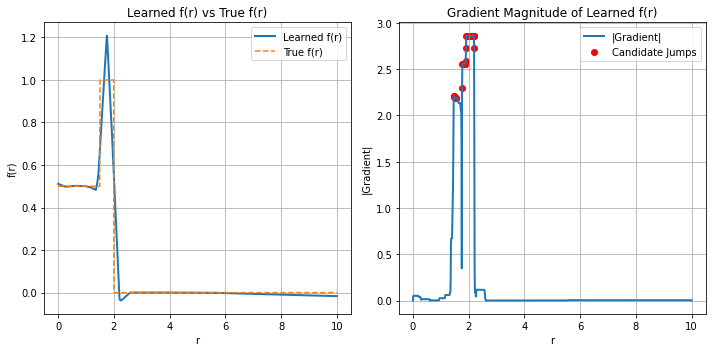

In [6]:
#After training is completed, sample and derive f to find discontinuities

r_dense = np.linspace(0, 10, 1000).astype(np.float32)  
r_dense_torch = torch.tensor(r_dense, device=device).unsqueeze(1)
with torch.no_grad():
    f_pred = f_model(r_dense_torch).cpu().numpy().flatten()

# 数值求导
f_pred_grad = np.zeros_like(f_pred)
f_pred_grad[1:-1] = (f_pred[2:] - f_pred[:-2]) / (r_dense[2:] - r_dense[:-2])

abs_grad = np.abs(f_pred_grad)
peak_indices = np.argsort(abs_grad)[-50:]  # Find the 50 points with the largest absolute gradient values
candidate_jumps = r_dense[peak_indices]
print("Candidate discontinuities:", candidate_jumps)

plt.figure(figsize=(10,5))
plt.subplot(1,2,1)
plt.plot(r_dense, f_pred, label='Learned f(r)', linewidth=2)
plt.plot(r_dense, f_true(r_dense), label='True f(r)', linestyle='--')
plt.xlabel('r')
plt.ylabel('f(r)')
plt.title('Learned f(r) vs True f(r)')
plt.legend()
plt.grid(True)

plt.subplot(1,2,2)
plt.plot(r_dense, abs_grad, label='|Gradient|', linewidth=2)
plt.scatter(candidate_jumps, abs_grad[peak_indices], color='r', label='Candidate Jumps')
plt.xlabel('r')
plt.ylabel('|Gradient|')
plt.title('Gradient Magnitude of Learned f(r)')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()